In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
credit_path = "../Data/processed/credit_default_clean.csv"

credit_df = pd.read_csv(credit_path)

print("Credit Risk Dataset")
print("=" * 70)
print(f"Rows    : {credit_df.shape[0]:,}")
print(f"Columns : {credit_df.shape[1]}")

display(credit_df.head())

Credit Risk Dataset
Rows    : 30,000
Columns : 25


,id,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt1,bill_amt2,bill_amt3,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default_payment_next_month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
print("Column Names:")
print(credit_df.columns.tolist())

Column Names:
['id', 'limit_bal', 'sex', 'education', 'marriage', 'age', 'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6', 'default_payment_next_month']


In [4]:
# Credit risk dataset overview

print("CREDIT RISK DATASET OVERVIEW")
print("=" * 80)

print(f"Rows    : {credit_df.shape[0]:,}")
print(f"Columns : {credit_df.shape[1]}")

print("\nData Types:")
display(credit_df.dtypes.to_frame("Data Type"))

print("\nMissing Values:")
credit_missing = pd.DataFrame({
    "missing_values": credit_df.isnull().sum(),
    "missing_percentage": (
        credit_df.isnull().sum() / len(credit_df) * 100
    ).round(2)
})

display(credit_missing)

print("\nDuplicate Rows:")
print(credit_df.duplicated().sum())

CREDIT RISK DATASET OVERVIEW
Rows    : 30,000
Columns : 25

Data Types:


,Data Type
id,int64
limit_bal,int64
sex,int64
education,int64
marriage,int64
age,int64
pay_0,int64
pay_2,int64
pay_3,int64
pay_4,int64



Missing Values:


,missing_values,missing_percentage
id,0,0.0
limit_bal,0,0.0
sex,0,0.0
education,0,0.0
marriage,0,0.0
age,0,0.0
pay_0,0,0.0
pay_2,0,0.0
pay_3,0,0.0
pay_4,0,0.0



Duplicate Rows:
0


In [5]:
# Target variable analysis

target = "default_payment_next_month"

print("TARGET VARIABLE ANALYSIS")
print("=" * 80)

print("\nUnique target values:")
print(credit_df[target].unique())

print("\nTarget counts:")
display(
    credit_df[target].value_counts()
)

print("\nTarget percentages:")
target_percentage = (
    credit_df[target]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(target_percentage)

TARGET VARIABLE ANALYSIS

Unique target values:
[1 0]

Target counts:


default_payment_next_month
0    23364
1     6636
Name: count, dtype: int64


Target percentages:


default_payment_next_month
0    77.88
1    22.12
Name: proportion, dtype: float64

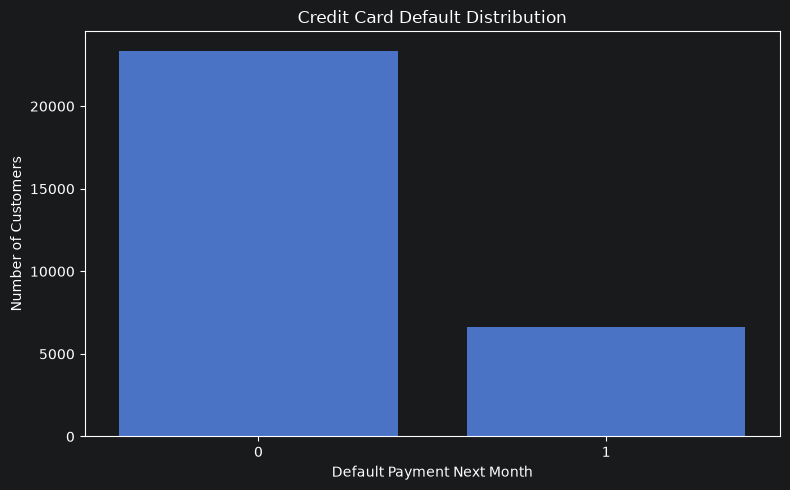

In [6]:
# Credit default distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=credit_df,
    x=target
)

plt.title("Credit Card Default Distribution")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [7]:
# Numerical feature summary

numeric_credit = credit_df.select_dtypes(
    include=np.number
)

display(
    numeric_credit.describe().T
)

,count,mean,std,min,25%,50%,75%,max
id,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
limit_bal,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
sex,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
education,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
marriage,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
age,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
pay_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
pay_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
pay_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
pay_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [8]:
# Unique value analysis

unique_summary = pd.DataFrame({
    "column": credit_df.columns,
    "unique_values": [
        credit_df[column].nunique()
        for column in credit_df.columns
    ]
})

display(unique_summary)

,column,unique_values
0,id,30000
1,limit_bal,81
2,sex,2
3,education,7
4,marriage,4
5,age,56
6,pay_0,11
7,pay_2,11
8,pay_3,11
9,pay_4,11


In [9]:
# Unique value analysis

unique_summary = pd.DataFrame({
    "column": credit_df.columns,
    "unique_values": [
        credit_df[column].nunique()
        for column in credit_df.columns
    ]
})

display(unique_summary)

,column,unique_values
0,id,30000
1,limit_bal,81
2,sex,2
3,education,7
4,marriage,4
5,age,56
6,pay_0,11
7,pay_2,11
8,pay_3,11
9,pay_4,11


In [10]:
# Inspect categorical/status variables

categorical_credit = [
    "sex",
    "education",
    "marriage",
    "pay_0",
    "pay_2",
    "pay_3",
    "pay_4",
    "pay_5",
    "pay_6"
]

for column in categorical_credit:
    print("\n" + "=" * 60)
    print(column)
    print("=" * 60)
    print(credit_df[column].value_counts().sort_index())


sex
sex
1    11888
2    18112
Name: count, dtype: int64

education
education
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

marriage
marriage
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

pay_0
pay_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

pay_2
pay_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

pay_3
pay_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

pay_4
pay_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

pay_5
pay_5
-2     4546
-1     5539
 0    169

In [11]:
X = credit_df.drop(
    columns=["id", "default_payment_next_month"]
)

y = credit_df["default_payment_next_month"]

In [12]:
# Create a separate dataframe for credit-risk modeling

credit_model = credit_df.copy()

print("Credit modeling dataset created.")
print(f"Shape: {credit_model.shape}")

Credit modeling dataset created.
Shape: (30000, 25)


In [13]:
# Clean education and marriage categories

credit_model["education_clean"] = credit_model["education"].replace({
    0: 4,
    5: 4,
    6: 4
})

credit_model["marriage_clean"] = credit_model["marriage"].replace({
    0: 3
})

print("Education values after cleaning:")
print(credit_model["education_clean"].value_counts().sort_index())

print("\nMarriage values after cleaning:")
print(credit_model["marriage_clean"].value_counts().sort_index())

Education values after cleaning:
education_clean
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

Marriage values after cleaning:
marriage_clean
1    13659
2    15964
3      377
Name: count, dtype: int64


In [14]:
# Repayment-status columns

pay_columns = [
    "pay_0",
    "pay_2",
    "pay_3",
    "pay_4",
    "pay_5",
    "pay_6"
]

print("Repayment columns:")
print(pay_columns)

Repayment columns:
['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']


In [15]:
# Create repayment behavior features

credit_model["num_delinquent_months"] = (
    credit_model[pay_columns] > 0
).sum(axis=1)

credit_model["max_delinquency"] = (
    credit_model[pay_columns]
    .clip(lower=0)
    .max(axis=1)
)

credit_model["avg_delinquency"] = (
    credit_model[pay_columns]
    .clip(lower=0)
    .mean(axis=1)
)

credit_model["recent_delinquency"] = (
    credit_model["pay_0"] > 0
).astype(int)

print("Delinquency features created.")

display(
    credit_model[
        [
            "pay_0",
            "pay_2",
            "pay_3",
            "pay_4",
            "pay_5",
            "pay_6",
            "num_delinquent_months",
            "max_delinquency",
            "avg_delinquency",
            "recent_delinquency"
        ]
    ].head(10)
)

Delinquency features created.


,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,num_delinquent_months,max_delinquency,avg_delinquency,recent_delinquency
0,2,2,-1,-1,-2,-2,2,2,0.666667,1
1,-1,2,0,0,0,2,2,2,0.666667,0
2,0,0,0,0,0,0,0,0,0.000000,0
3,0,0,0,0,0,0,0,0,0.000000,0
4,-1,0,-1,0,0,0,0,0,0.000000,0
5,0,0,0,0,0,0,0,0,0.000000,0
6,0,0,0,0,0,0,0,0,0.000000,0
7,0,-1,-1,0,0,-1,0,0,0.000000,0
8,0,0,2,0,0,0,1,2,0.333333,0
9,-2,-2,-2,-2,-1,-1,0,0,0.000000,0


In [16]:
# Bill amount features

bill_columns = [
    "bill_amt1",
    "bill_amt2",
    "bill_amt3",
    "bill_amt4",
    "bill_amt5",
    "bill_amt6"
]

credit_model["total_bill_amount"] = (
    credit_model[bill_columns].sum(axis=1)
)

credit_model["average_bill_amount"] = (
    credit_model[bill_columns].mean(axis=1)
)

credit_model["maximum_bill_amount"] = (
    credit_model[bill_columns].max(axis=1)
)

credit_model["minimum_bill_amount"] = (
    credit_model[bill_columns].min(axis=1)
)

credit_model["bill_amount_change"] = (
    credit_model["bill_amt1"]
    - credit_model["bill_amt6"]
)

print("Bill amount features created.")

display(
    credit_model[
        [
            "total_bill_amount",
            "average_bill_amount",
            "maximum_bill_amount",
            "minimum_bill_amount",
            "bill_amount_change"
        ]
    ].head()
)

Bill amount features created.


,total_bill_amount,average_bill_amount,maximum_bill_amount,minimum_bill_amount,bill_amount_change
0,7704,1284.000000,3913,0,3913
1,17077,2846.166667,3455,1725,-579
2,101653,16942.166667,29239,13559,13690
3,231334,38555.666667,49291,28314,17443
4,109339,18223.166667,35835,5670,-10514


In [17]:
# Payment amount features

payment_columns = [
    "pay_amt1",
    "pay_amt2",
    "pay_amt3",
    "pay_amt4",
    "pay_amt5",
    "pay_amt6"
]

credit_model["total_payment_amount"] = (
    credit_model[payment_columns].sum(axis=1)
)

credit_model["average_payment_amount"] = (
    credit_model[payment_columns].mean(axis=1)
)

credit_model["maximum_payment_amount"] = (
    credit_model[payment_columns].max(axis=1)
)

print("Payment features created.")

display(
    credit_model[
        [
            "total_payment_amount",
            "average_payment_amount",
            "maximum_payment_amount"
        ]
    ].head()
)

Payment features created.


,total_payment_amount,average_payment_amount,maximum_payment_amount
0,689,114.833333,689
1,5000,833.333333,2000
2,11018,1836.333333,5000
3,8388,1398.000000,2019
4,59049,9841.500000,36681


In [18]:
# Payment-to-bill ratio

credit_model["payment_to_bill_ratio"] = np.where(
    credit_model["total_bill_amount"] > 0,
    credit_model["total_payment_amount"]
    / credit_model["total_bill_amount"],
    0
)

credit_model["payment_to_bill_ratio"] = (
    credit_model["payment_to_bill_ratio"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print("Payment-to-bill ratio created.")

display(
    credit_model["payment_to_bill_ratio"].describe()
)

Payment-to-bill ratio created.


count    30000.000000
mean         0.469158
std          5.506705
min          0.000000
25%          0.040952
50%          0.084932
75%          0.586922
max        797.000000
Name: payment_to_bill_ratio, dtype: float64

In [19]:
# Credit utilization features

credit_model["average_credit_utilization"] = np.where(
    credit_model["limit_bal"] > 0,
    credit_model["average_bill_amount"]
    / credit_model["limit_bal"],
    0
)

credit_model["maximum_credit_utilization"] = np.where(
    credit_model["limit_bal"] > 0,
    credit_model["maximum_bill_amount"]
    / credit_model["limit_bal"],
    0
)

credit_model[
    [
        "average_credit_utilization",
        "maximum_credit_utilization"
    ]
].describe()

,average_credit_utilization,maximum_credit_utilization
count,30000.000000,30000.000000
mean,0.373048,0.494965
std,0.351890,0.433046
min,-0.232590,-0.100000
25%,0.029997,0.070636
50%,0.284834,0.430702
75%,0.687929,0.923246
max,5.364308,10.688575


In [20]:
# Feature engineering summary

print("CREDIT RISK FEATURE ENGINEERING")
print("=" * 80)

print(f"Original features: {credit_df.shape[1]}")
print(f"Engineered features: {credit_model.shape[1]}")

print("\nNew features:")

new_features = [
    column for column in credit_model.columns
    if column not in credit_df.columns
]

for feature in new_features:
    print("-", feature)

CREDIT RISK FEATURE ENGINEERING
Original features: 25
Engineered features: 42

New features:
- education_clean
- marriage_clean
- num_delinquent_months
- max_delinquency
- avg_delinquency
- recent_delinquency
- total_bill_amount
- average_bill_amount
- maximum_bill_amount
- minimum_bill_amount
- bill_amount_change
- total_payment_amount
- average_payment_amount
- maximum_payment_amount
- payment_to_bill_ratio
- average_credit_utilization
- maximum_credit_utilization


In [21]:
# Target distribution

target = "default_payment_next_month"

target_counts = credit_model[target].value_counts()

target_percentages = (
    credit_model[target]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "customers": target_counts,
    "percentage": target_percentages
})

display(target_summary)

,customers,percentage
default_payment_next_month,,
0,23364,77.88
1,6636,22.12


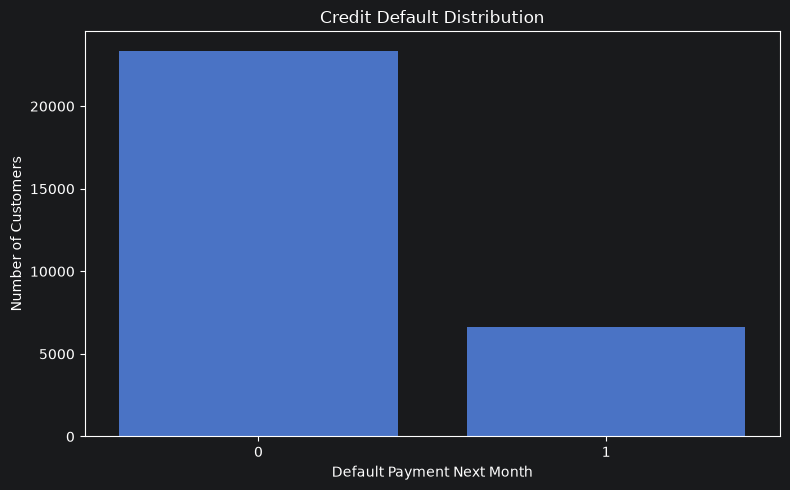

In [22]:
# Visualize target distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=credit_model,
    x=target
)

plt.title("Credit Default Distribution")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [23]:
# Exact target distribution

target = "default_payment_next_month"

target_summary = (
    credit_model[target]
    .value_counts()
    .sort_index()
    .to_frame("customers")
)

target_summary["percentage"] = (
    target_summary["customers"]
    / len(credit_model)
    * 100
).round(2)

display(target_summary)

,customers,percentage
default_payment_next_month,,
0,23364,77.88
1,6636,22.12


In [24]:
# Prepare features and target

target = "default_payment_next_month"

X = credit_model.drop(
    columns=[
        "id",
        target
    ]
).copy()

y = credit_model[target].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (30000, 40)
Target shape: (30000,)

Target distribution:
default_payment_next_month
0    23364
1     6636
Name: count, dtype: int64


In [25]:
# Remove original versions after creating cleaned versions

X = X.drop(
    columns=[
        "education",
        "marriage"
    ]
)

print("Updated feature count:", X.shape[1])
print("\nFeatures:")
print(X.columns.tolist())

Updated feature count: 38

Features:
['limit_bal', 'sex', 'age', 'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6', 'education_clean', 'marriage_clean', 'num_delinquent_months', 'max_delinquency', 'avg_delinquency', 'recent_delinquency', 'total_bill_amount', 'average_bill_amount', 'maximum_bill_amount', 'minimum_bill_amount', 'bill_amount_change', 'total_payment_amount', 'average_payment_amount', 'maximum_payment_amount', 'payment_to_bill_ratio', 'average_credit_utilization', 'maximum_credit_utilization']


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("TRAIN / TEST SPLIT")
print("=" * 60)

print(f"Training rows: {len(X_train):,}")
print(f"Testing rows : {len(X_test):,}")

print("\nTraining target distribution:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTesting target distribution:")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

TRAIN / TEST SPLIT
Training rows: 24,000
Testing rows : 6,000

Training target distribution:
default_payment_next_month
0    77.88
1    22.12
Name: proportion, dtype: float64

Testing target distribution:
default_payment_next_month
0    77.88
1    22.12
Name: proportion, dtype: float64


In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_pred = logistic_pipeline.predict(X_test)

y_probability = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

print("LOGISTIC REGRESSION RESULTS")
print("=" * 70)

print(
    "Accuracy :",
    round(accuracy_score(y_test, y_pred), 4)
)

print(
    "Precision:",
    round(precision_score(y_test, y_pred), 4)
)

print(
    "Recall   :",
    round(recall_score(y_test, y_pred), 4)
)

print(
    "F1 Score :",
    round(f1_score(y_test, y_pred), 4)
)

print(
    "ROC-AUC  :",
    round(roc_auc_score(y_test, y_probability), 4)
)

LOGISTIC REGRESSION RESULTS
Accuracy : 0.7412
Precision: 0.4378
Recall   : 0.5998
F1 Score : 0.5062
ROC-AUC  : 0.7502


In [30]:
print("\nClassification Report")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred
    )
)


Classification Report
              precision    recall  f1-score   support

           0       0.87      0.78      0.82      4673
           1       0.44      0.60      0.51      1327

    accuracy                           0.74      6000
   macro avg       0.66      0.69      0.67      6000
weighted avg       0.78      0.74      0.75      6000



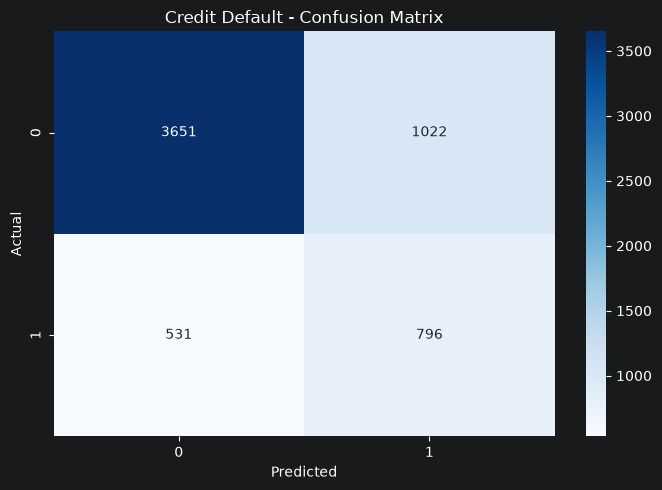

In [31]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Credit Default - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

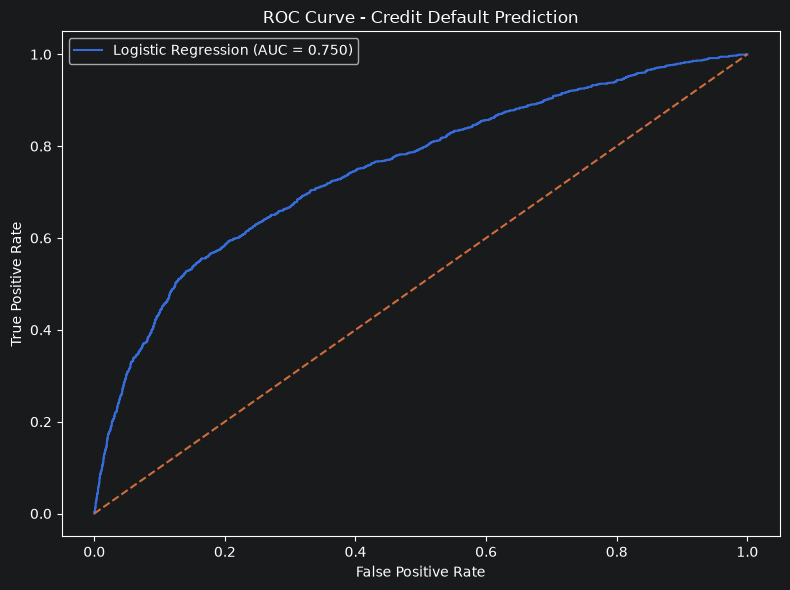

In [32]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

auc_score = roc_auc_score(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve - Credit Default Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [34]:
# Random Forest predictions

rf_pred = rf_model.predict(X_test)

rf_probability = rf_model.predict_proba(
    X_test
)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_probability)

print("RANDOM FOREST RESULTS")
print("=" * 70)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

RANDOM FOREST RESULTS
Accuracy : 0.7758
Precision: 0.4944
Recall   : 0.5961
F1 Score : 0.5405
ROC-AUC  : 0.7778


In [35]:
print("\nClassification Report")
print("=" * 70)

print(
    classification_report(
        y_test,
        rf_pred
    )
)


Classification Report
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      4673
           1       0.49      0.60      0.54      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.79      0.78      0.78      6000



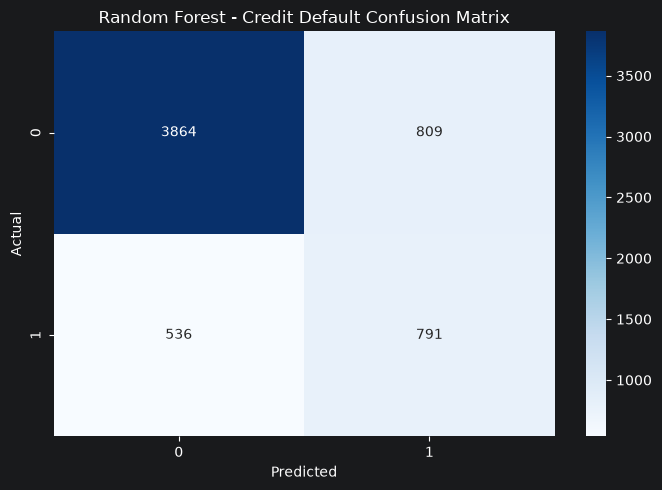

In [36]:
# Random Forest confusion matrix

rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest - Credit Default Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

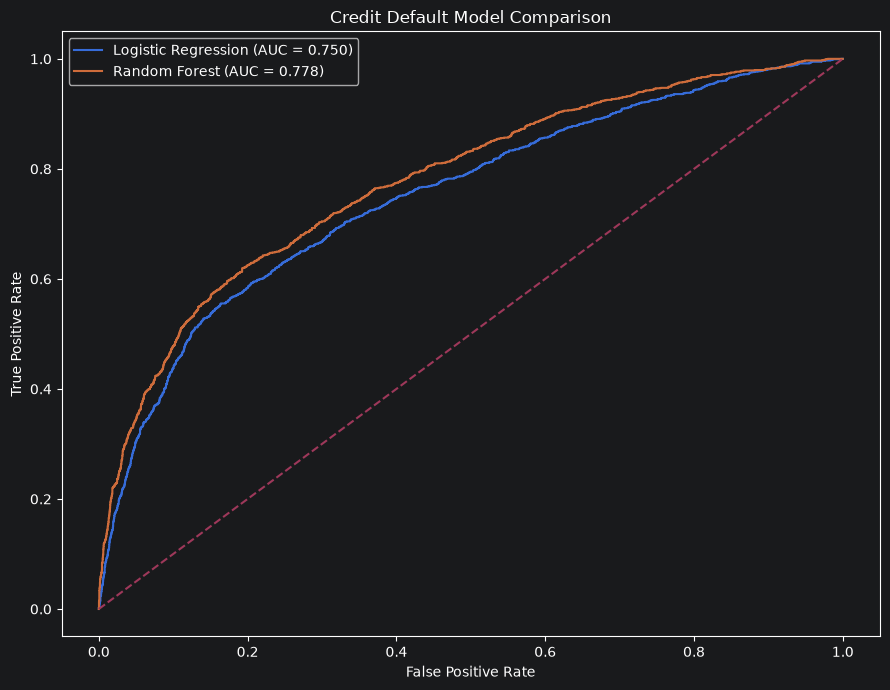

In [37]:
# Compare Logistic Regression and Random Forest ROC curves

logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    y_probability
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_probability
)

logistic_auc = roc_auc_score(
    y_test,
    y_probability
)

rf_auc = roc_auc_score(
    y_test,
    rf_probability
)

plt.figure(figsize=(9, 7))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("Credit Default Model Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

In [38]:
# Model performance comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        rf_accuracy
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        rf_precision
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        rf_recall
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        rf_f1
    ],
    "ROC-AUC": [
        logistic_auc,
        rf_auc
    ]
})

model_comparison = model_comparison.round(4)

display(model_comparison)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7412,0.4378,0.5998,0.5062,0.7502
1,Random Forest,0.7758,0.4944,0.5961,0.5405,0.7778


In [39]:
# Random Forest feature importance

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    feature_importance.head(20)
)

,feature,importance
0,pay_0,0.078823
1,num_delinquent_months,0.077760
2,max_delinquency,0.076962
3,avg_delinquency,0.076372
4,recent_delinquency,0.063997
5,maximum_credit_utilization,0.033148
6,average_credit_utilization,0.029707
7,total_payment_amount,0.027010
8,payment_to_bill_ratio,0.026427
9,pay_2,0.025879


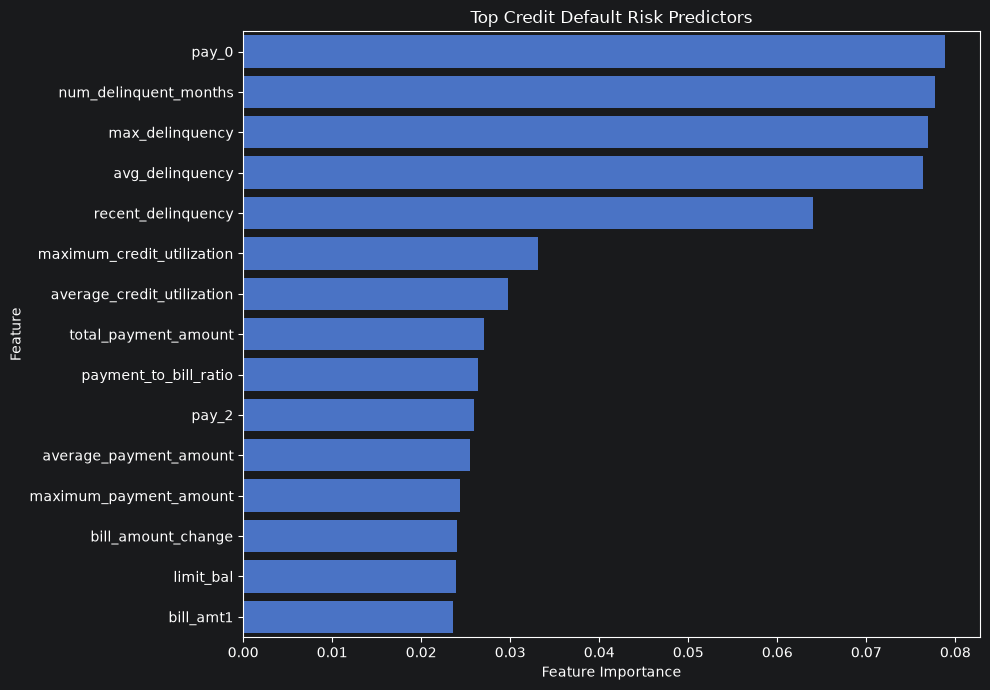

In [40]:
# Top 15 feature importances

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top Credit Default Risk Predictors")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [41]:
# Random Forest evaluation

rf_pred = rf_model.predict(X_test)

rf_probability = rf_model.predict_proba(
    X_test
)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_probability)

print("RANDOM FOREST RESULTS")
print("=" * 70)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

RANDOM FOREST RESULTS
Accuracy : 0.7758
Precision: 0.4944
Recall   : 0.5961
F1 Score : 0.5405
ROC-AUC  : 0.7778


In [42]:
print("\nClassification Report")
print("=" * 70)

print(
    classification_report(
        y_test,
        rf_pred
    )
)


Classification Report
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      4673
           1       0.49      0.60      0.54      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.79      0.78      0.78      6000



In [43]:
# Compare Logistic Regression vs Random Forest

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        rf_accuracy
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        rf_precision
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        rf_recall
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        rf_f1
    ],
    "ROC-AUC": [
        logistic_auc,
        rf_auc
    ]
})

display(model_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7412,0.4378,0.5998,0.5062,0.7502
1,Random Forest,0.7758,0.4944,0.5961,0.5405,0.7778


In [45]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [46]:
# Calculate class imbalance ratio

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative class:", negative_count)
print("Positive class:", positive_count)
print("Scale Pos Weight:", round(scale_pos_weight, 2))

Negative class: 18691
Positive class: 5309
Scale Pos Weight: 3.52


In [47]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [48]:
# XGBoost predictions

xgb_pred = xgb_model.predict(X_test)

xgb_probability = xgb_model.predict_proba(
    X_test
)[:, 1]

xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_precision = precision_score(
    y_test,
    xgb_pred
)

xgb_recall = recall_score(
    y_test,
    xgb_pred
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred
)

xgb_auc = roc_auc_score(
    y_test,
    xgb_probability
)

print("XGBOOST RESULTS")
print("=" * 70)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_auc:.4f}")

XGBOOST RESULTS
Accuracy : 0.7590
Precision: 0.4666
Recall   : 0.6255
F1 Score : 0.5344
ROC-AUC  : 0.7768


In [49]:
# Final model comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        logistic_auc,
        rf_auc,
        xgb_auc
    ]
})

model_comparison = model_comparison.round(4)

display(
    model_comparison.sort_values(
        "ROC-AUC",
        ascending=False
    )
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.7758,0.4944,0.5961,0.5405,0.7778
2,XGBoost,0.7590,0.4666,0.6255,0.5344,0.7768
0,Logistic Regression,0.7412,0.4378,0.5998,0.5062,0.7502


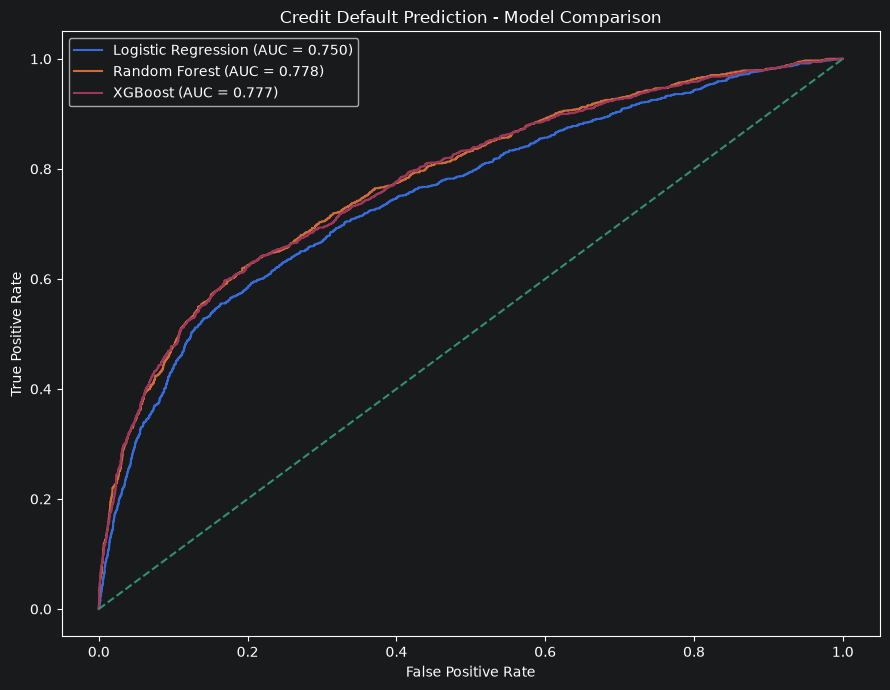

In [50]:
# ROC curve comparison

xgb_fpr, xgb_tpr, _ = roc_curve(
    y_test,
    xgb_probability
)

plt.figure(figsize=(9, 7))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost (AUC = {xgb_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("Credit Default Prediction - Model Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

In [51]:
# XGBoost feature importance

xgb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
})

xgb_importance = (
    xgb_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    xgb_importance.head(20)
)

,feature,importance
0,num_delinquent_months,0.304827
1,max_delinquency,0.237513
2,recent_delinquency,0.078940
3,pay_0,0.063331
4,avg_delinquency,0.048642
5,average_bill_amount,0.012037
6,total_payment_amount,0.011468
7,maximum_credit_utilization,0.010061
8,pay_4,0.009507
9,limit_bal,0.009489


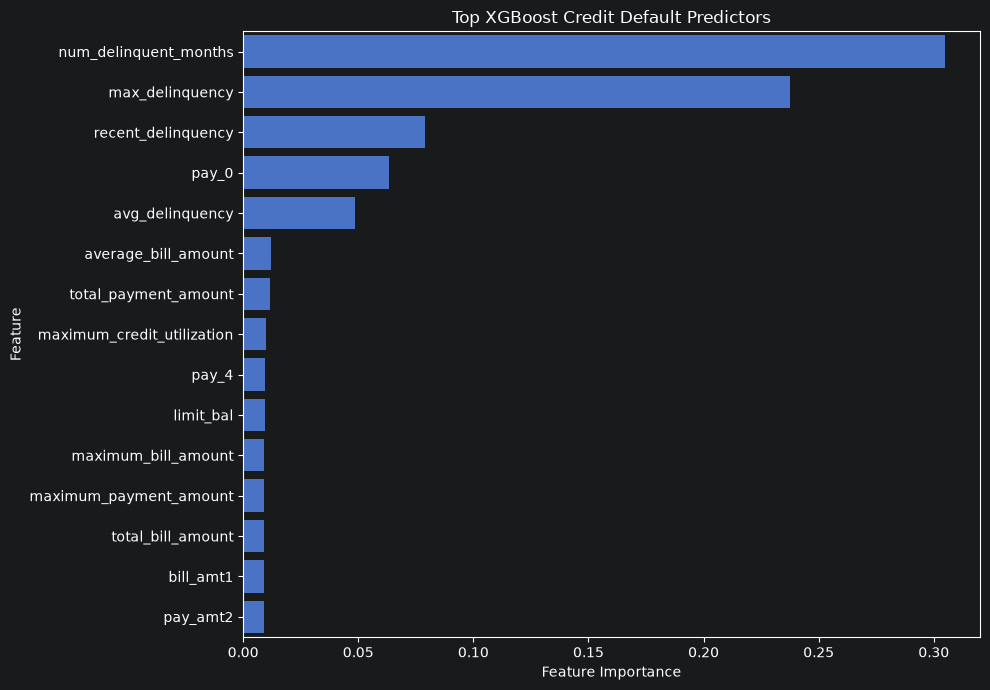

In [52]:
# Top XGBoost risk predictors

top_xgb_features = xgb_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_xgb_features,
    x="importance",
    y="feature"
)

plt.title("Top XGBoost Credit Default Predictors")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [53]:
# XGBoost evaluation

print("XGBOOST RESULTS")
print("=" * 70)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_auc:.4f}")

print("\nClassification Report")
print("=" * 70)

print(
    classification_report(
        y_test,
        xgb_pred
    )
)

XGBOOST RESULTS
Accuracy : 0.7590
Precision: 0.4666
Recall   : 0.6255
F1 Score : 0.5344
ROC-AUC  : 0.7768

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      4673
           1       0.47      0.63      0.53      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.71      0.69      6000
weighted avg       0.79      0.76      0.77      6000



In [54]:
# Final comparison of all models

display(
    model_comparison
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.7758,0.4944,0.5961,0.5405,0.7778
1,XGBoost,0.7590,0.4666,0.6255,0.5344,0.7768
2,Logistic Regression,0.7412,0.4378,0.5998,0.5062,0.7502


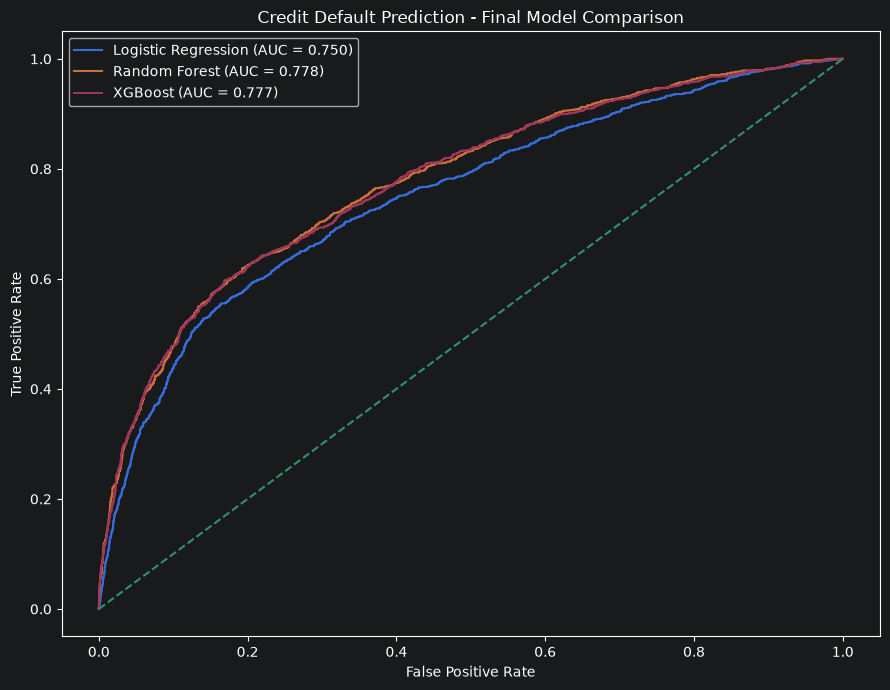

In [55]:
# Final ROC curve comparison

plt.figure(figsize=(9, 7))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost (AUC = {xgb_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("Credit Default Prediction - Final Model Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

In [56]:
# Credit Risk Scoring Engine

final_model = rf_model

# Predict probability of default
default_probability = final_model.predict_proba(X_test)[:, 1]

# Convert probability into a 0-100 risk score
risk_score = default_probability * 100

# Create risk categories
def assign_risk_level(score):
    if score < 25:
        return "Low"
    elif score < 50:
        return "Moderate"
    elif score < 75:
        return "High"
    else:
        return "Very High"


risk_level = [
    assign_risk_level(score)
    for score in risk_score
]

print("Credit Risk Scoring Engine created successfully.")

Credit Risk Scoring Engine created successfully.


In [57]:
# Create customer risk results

risk_results = credit_model.loc[
    X_test.index,
    [
        "id",
        "limit_bal",
        "age",
        "num_delinquent_months",
        "max_delinquency",
        "average_credit_utilization",
        "payment_to_bill_ratio",
        "default_payment_next_month"
    ]
].copy()

risk_results["default_probability"] = (
    default_probability
)

risk_results["risk_score"] = (
    risk_score.round(2)
)

risk_results["risk_level"] = risk_level

risk_results = risk_results.sort_values(
    "risk_score",
    ascending=False
).reset_index(drop=True)

print("Customer risk table created.")
print(f"Rows: {len(risk_results):,}")

display(
    risk_results.head(10)
)

Customer risk table created.
Rows: 6,000


,id,limit_bal,age,num_delinquent_months,max_delinquency,average_credit_utilization,payment_to_bill_ratio,default_payment_next_month,default_probability,risk_score,risk_level
0,1957,220000,42,6,2,0.011364,0.0,1,0.987686,98.77,Very High
1,27537,250000,51,6,3,0.009948,0.0,1,0.987121,98.71,Very High
2,28055,20000,32,6,7,0.120000,0.0,1,0.984911,98.49,Very High
3,28748,50000,28,6,7,0.048000,0.0,0,0.984763,98.48,Very High
4,20722,20000,37,6,7,0.120000,0.0,1,0.982657,98.27,Very High
5,29771,20000,31,6,7,0.120000,0.0,1,0.981302,98.13,Very High
6,16789,30000,37,6,7,0.079300,0.0,1,0.978775,97.88,Very High
7,6272,10000,23,6,7,0.230000,0.0,1,0.976470,97.65,Very High
8,13740,40000,43,6,7,0.060000,0.0,1,0.976151,97.62,Very High
9,29727,60000,36,6,7,0.038333,0.0,1,0.975206,97.52,Very High


In [58]:
# Risk level distribution

risk_distribution = (
    risk_results["risk_level"]
    .value_counts()
    .reindex(
        ["Low", "Moderate", "High", "Very High"],
        fill_value=0
    )
    .to_frame("customers")
)

risk_distribution["percentage"] = (
    risk_distribution["customers"]
    / len(risk_results)
    * 100
).round(2)

display(risk_distribution)

,customers,percentage
risk_level,,
Low,1864,31.07
Moderate,2536,42.27
High,904,15.07
Very High,696,11.60


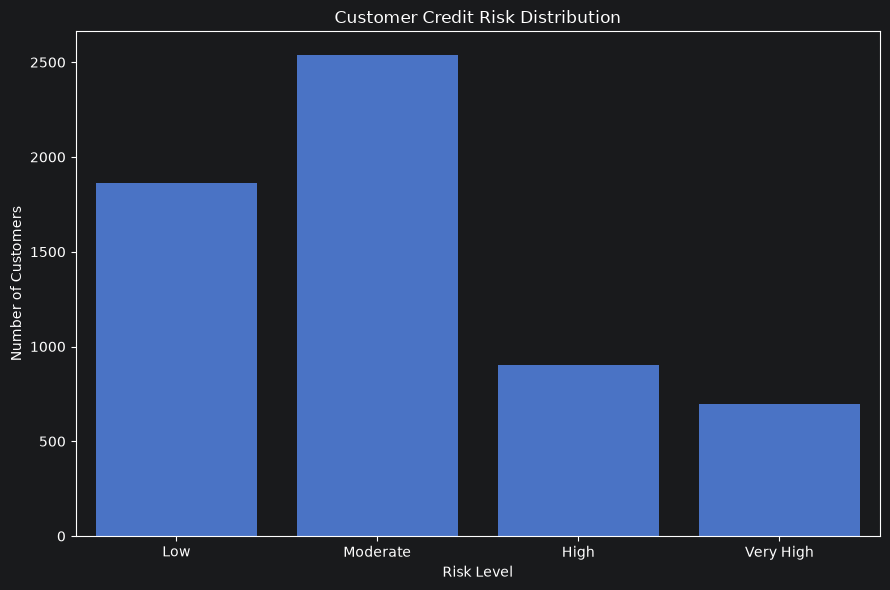

In [59]:
# Risk level distribution chart

plt.figure(figsize=(9, 6))

sns.countplot(
    data=risk_results,
    x="risk_level",
    order=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

plt.title("Customer Credit Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

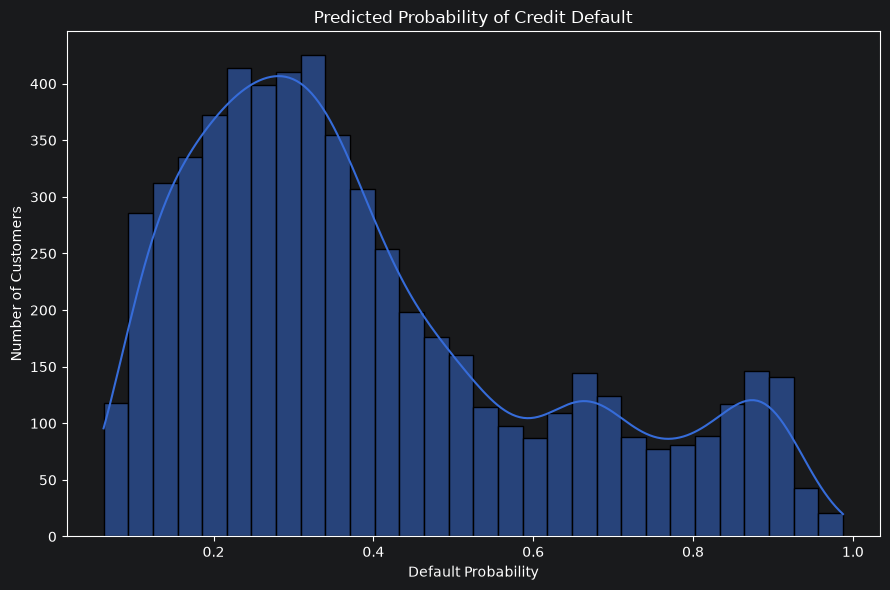

In [60]:
# Default probability distribution

plt.figure(figsize=(9, 6))

sns.histplot(
    risk_results["default_probability"],
    bins=30,
    kde=True
)

plt.title("Predicted Probability of Credit Default")
plt.xlabel("Default Probability")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [61]:
# Highest-risk customers

high_risk_customers = (
    risk_results[
        risk_results["risk_level"].isin(
            ["High", "Very High"]
        )
    ]
    .sort_values(
        "risk_score",
        ascending=False
    )
)

print(
    f"High / Very High risk customers: "
    f"{len(high_risk_customers):,}"
)

display(
    high_risk_customers.head(20)
)

High / Very High risk customers: 1,600


,id,limit_bal,age,num_delinquent_months,max_delinquency,average_credit_utilization,payment_to_bill_ratio,default_payment_next_month,default_probability,risk_score,risk_level
0,1957,220000,42,6,2,0.011364,0.0,1,0.987686,98.77,Very High
1,27537,250000,51,6,3,0.009948,0.0,1,0.987121,98.71,Very High
2,28055,20000,32,6,7,0.120000,0.0,1,0.984911,98.49,Very High
3,28748,50000,28,6,7,0.048000,0.0,0,0.984763,98.48,Very High
4,20722,20000,37,6,7,0.120000,0.0,1,0.982657,98.27,Very High
5,29771,20000,31,6,7,0.120000,0.0,1,0.981302,98.13,Very High
6,16789,30000,37,6,7,0.079300,0.0,1,0.978775,97.88,Very High
7,6272,10000,23,6,7,0.230000,0.0,1,0.976470,97.65,Very High
8,13740,40000,43,6,7,0.060000,0.0,1,0.976151,97.62,Very High
9,29727,60000,36,6,7,0.038333,0.0,1,0.975206,97.52,Very High


In [62]:
# Risk group profile

risk_profile = (
    risk_results
    .groupby("risk_level")
    .agg(
        customers=("id", "count"),
        avg_risk_score=("risk_score", "mean"),
        avg_default_probability=(
            "default_probability",
            "mean"
        ),
        avg_credit_limit=("limit_bal", "mean"),
        avg_age=("age", "mean"),
        avg_delinquent_months=(
            "num_delinquent_months",
            "mean"
        ),
        avg_max_delinquency=(
            "max_delinquency",
            "mean"
        ),
        avg_credit_utilization=(
            "average_credit_utilization",
            "mean"
        ),
        avg_payment_to_bill=(
            "payment_to_bill_ratio",
            "mean"
        )
    )
    .reindex(
        ["Low", "Moderate", "High", "Very High"]
    )
)

display(
    risk_profile.round(3)
)

,customers,avg_risk_score,avg_default_probability,avg_credit_limit,avg_age,avg_delinquent_months,avg_max_delinquency,avg_credit_utilization,avg_payment_to_bill
risk_level,,,,,,,,,
Low,1864,17.145,0.171,240724.249,35.413,0.011,0.015,0.294,0.362
Moderate,2536,35.405,0.354,149857.129,35.950,0.254,0.355,0.375,0.620
High,904,61.969,0.620,121825.221,35.830,1.800,1.614,0.359,0.329
Very High,696,85.842,0.858,98994.253,35.364,3.848,2.428,0.626,0.055


In [63]:
# Save credit risk predictions

risk_results.to_csv(
    "../Data/processed/customer_credit_risk_predictions.csv",
    index=False
)

risk_profile.to_csv(
    "../Data/processed/credit_risk_profile.csv"
)

model_comparison.to_csv(
    "../Data/processed/credit_model_comparison.csv",
    index=False
)

print("Credit risk outputs saved successfully.")

Credit risk outputs saved successfully.


In [66]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [67]:
# SHAP explainer for Random Forest

explainer = shap.TreeExplainer(rf_model)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [68]:
# Calculate SHAP values on a sample

X_shap = X_test.sample(
    n=min(2000, len(X_test)),
    random_state=42
)

shap_values = explainer.shap_values(X_shap)

print("SHAP values calculated successfully.")
print("Sample size:", len(X_shap))

SHAP values calculated successfully.
Sample size: 2000


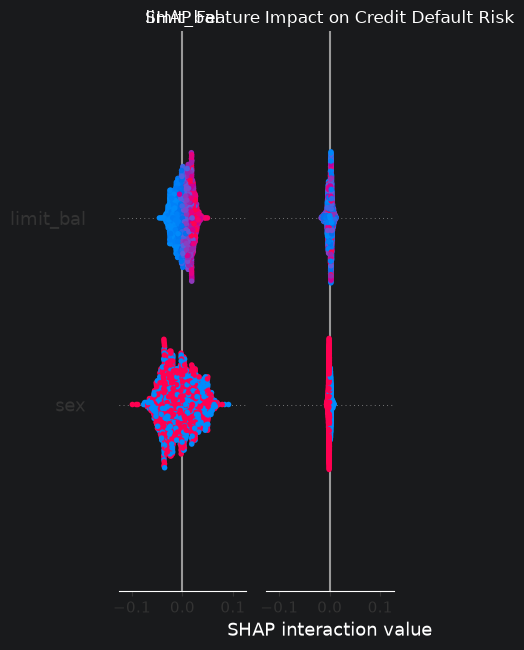

In [69]:
# SHAP global feature importance

shap.summary_plot(
    shap_values,
    X_shap,
    show=False
)

plt.title("SHAP Feature Impact on Credit Default Risk")
plt.tight_layout()
plt.show()

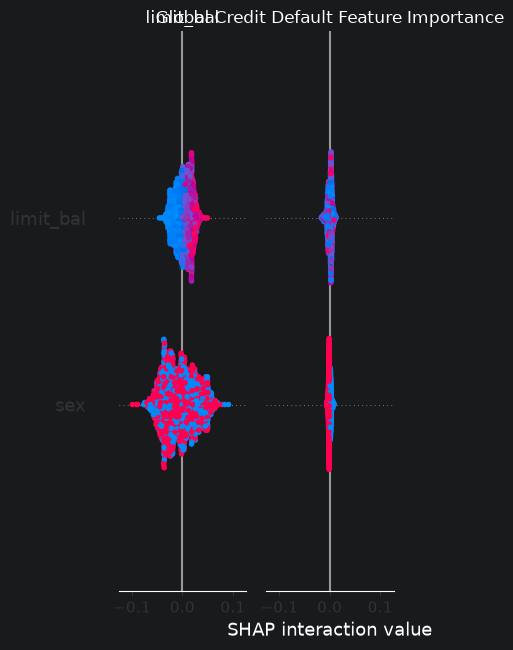

In [70]:
# SHAP global importance - bar chart

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=False
)

plt.title("Global Credit Default Feature Importance")
plt.tight_layout()
plt.show()

In [72]:
# Check SHAP output structure

print("SHAP values type:", type(shap_values))

if isinstance(shap_values, list):
    print("SHAP values is a list")
    print("Number of outputs:", len(shap_values))
    for i, values in enumerate(shap_values):
        print(f"Output {i} shape:", values.shape)

else:
    print("SHAP values shape:", shap_values.shape)

SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (2000, 38, 2)


In [73]:
# Calculate mean absolute SHAP importance
# Compatible with newer SHAP output formats

if isinstance(shap_values, list):

    # Binary classification:
    # use SHAP values for class 1 = default
    shap_for_default = shap_values[1]

elif len(shap_values.shape) == 3:

    # Shape:
    # (samples, features, classes)
    shap_for_default = shap_values[:, :, 1]

else:

    # Already 2-dimensional
    shap_for_default = shap_values


shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(
        shap_for_default
    ).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    shap_importance.head(20)
)

,feature,mean_abs_shap
0,max_delinquency,0.036428
1,pay_0,0.033988
2,avg_delinquency,0.033768
3,num_delinquent_months,0.033522
4,recent_delinquency,0.027472
5,maximum_credit_utilization,0.014979
6,average_credit_utilization,0.014001
7,limit_bal,0.013329
8,total_payment_amount,0.010607
9,pay_2,0.009617


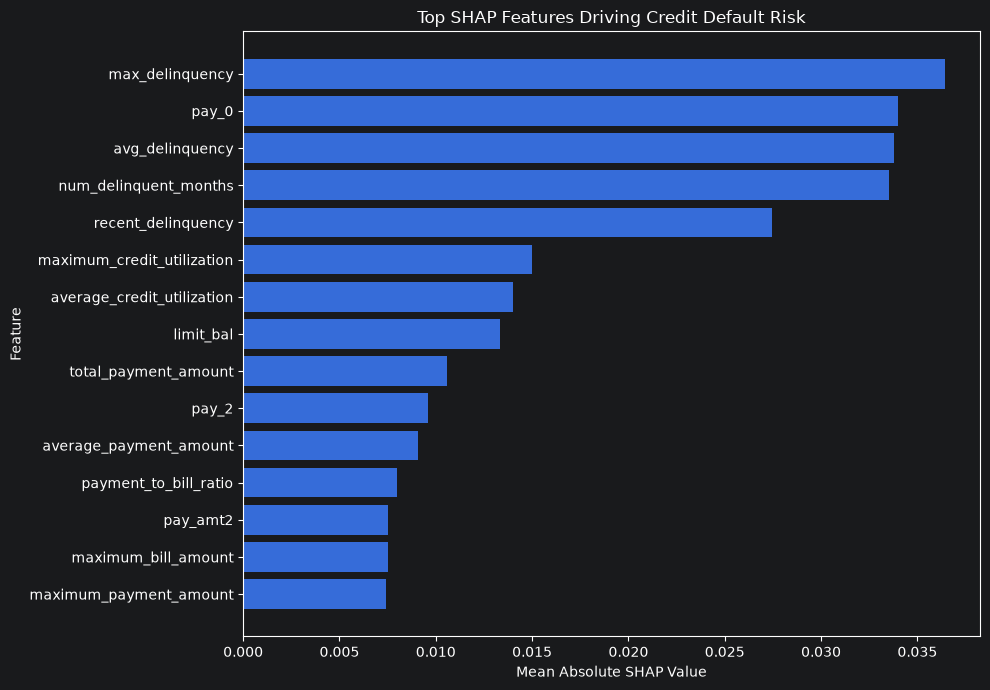

In [74]:
# Global SHAP feature importance

plt.figure(figsize=(10, 7))

top_shap = shap_importance.head(15).sort_values(
    "mean_abs_shap"
)

plt.barh(
    top_shap["feature"],
    top_shap["mean_abs_shap"]
)

plt.title("Top SHAP Features Driving Credit Default Risk")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

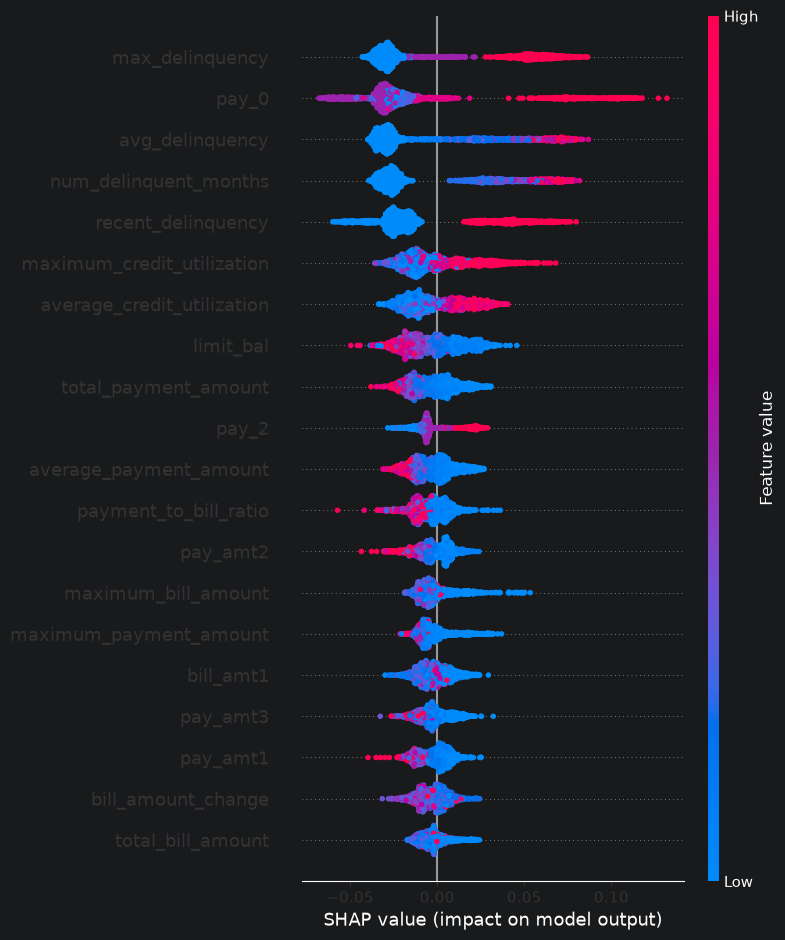

In [75]:
# SHAP summary plot for default class

shap.summary_plot(
    shap_for_default,
    X_shap
)

In [76]:
print("Expected value:")
print(explainer.expected_value)

Expected value:
[0.50020208 0.49979792]


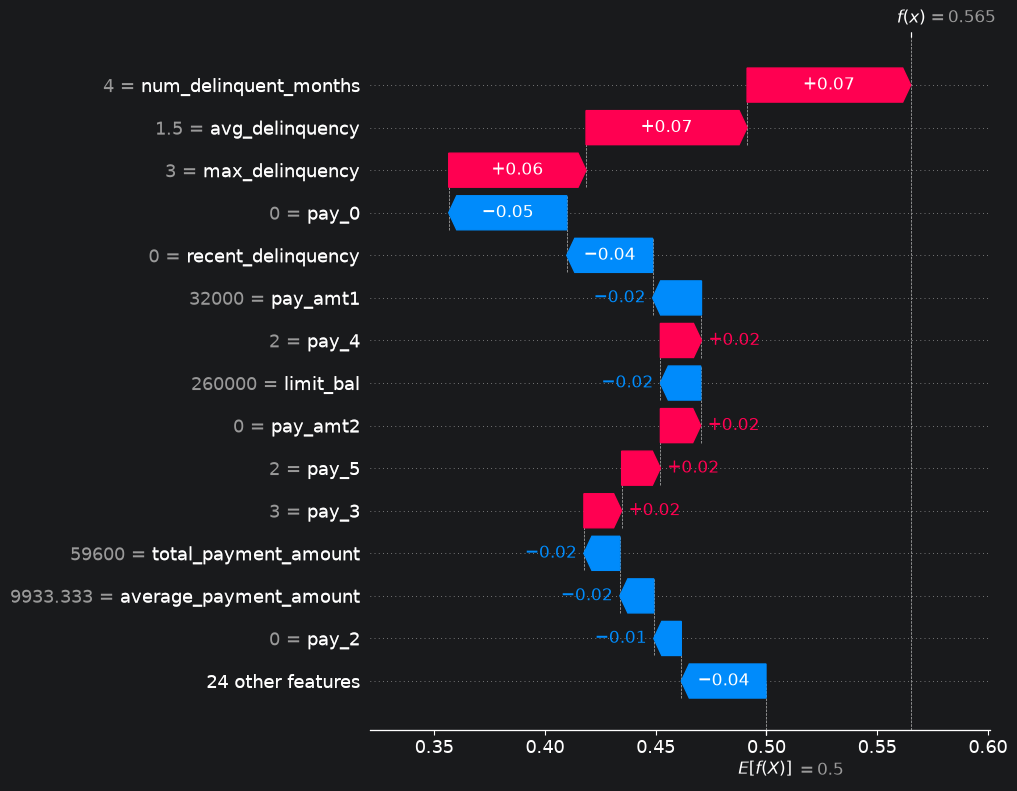

In [77]:
# Individual customer SHAP explanation
# Explains why the model predicts default risk for one customer

customer_index = 0

customer_shap_values = shap_for_default[customer_index]

customer_explanation = shap.Explanation(
    values=customer_shap_values,
    base_values=explainer.expected_value[1],
    data=X_shap.iloc[customer_index],
    feature_names=X_shap.columns
)

shap.plots.waterfall(
    customer_explanation,
    max_display=15
)

In [78]:
# Find the highest-risk customer in the SHAP sample

risk_probabilities = rf_model.predict_proba(X_shap)[:, 1]

high_risk_index = np.argmax(risk_probabilities)

print("High-Risk Customer Index:", high_risk_index)
print(
    "Predicted Default Probability:",
    round(risk_probabilities[high_risk_index], 4)
)

High-Risk Customer Index: 981
Predicted Default Probability: 0.9813


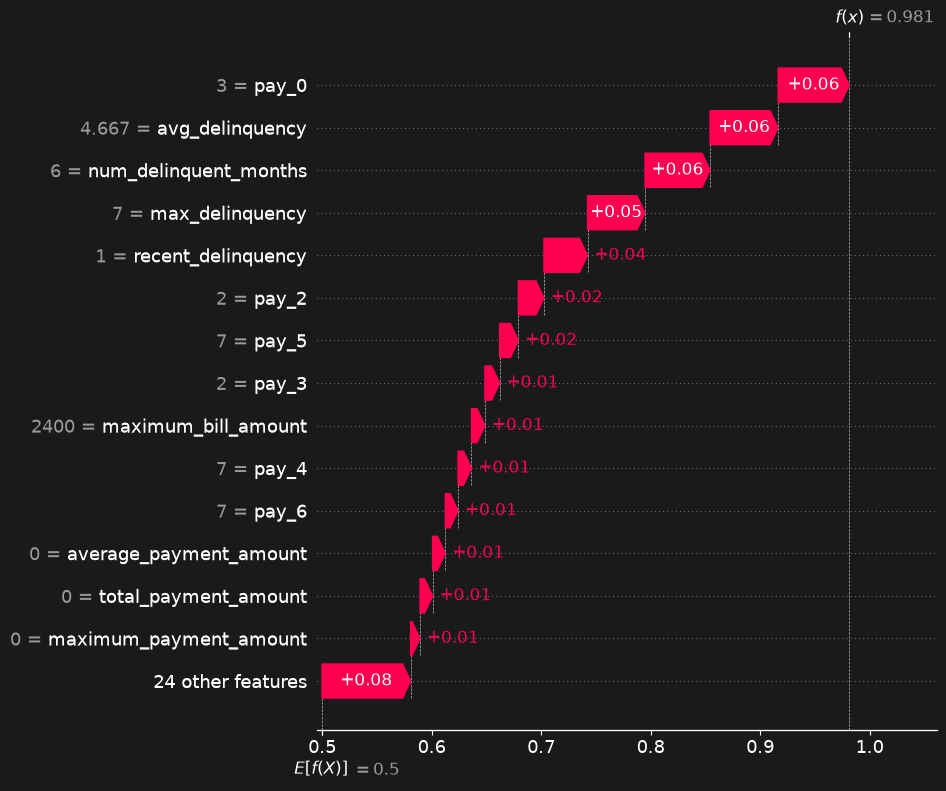

In [79]:
# SHAP explanation for highest-risk customer

high_risk_explanation = shap.Explanation(
    values=shap_for_default[high_risk_index],
    base_values=explainer.expected_value[1],
    data=X_shap.iloc[high_risk_index],
    feature_names=X_shap.columns
)

shap.plots.waterfall(
    high_risk_explanation,
    max_display=15
)

In [80]:
# Save SHAP feature importance

shap_importance.to_csv(
    "../Data/processed/shap_feature_importance.csv",
    index=False
)

print("SHAP feature importance saved successfully.")

SHAP feature importance saved successfully.


In [81]:
# Save SHAP values for reproducibility

shap_values_df = pd.DataFrame(
    shap_for_default,
    columns=X_shap.columns
)

shap_values_df.to_csv(
    "../Data/processed/shap_values_default_class.csv",
    index=False
)

print("SHAP values saved successfully.")

SHAP values saved successfully.
